# Phishing URL Detection — ANN Training Pipeline

Trains a Keras ANN on the PhiUSIIL phishing URL dataset using the same
feature-extraction logic as the deployed Streamlit app, so that the
saved model, scaler, and feature list stay consistent between training
and inference.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
from urllib.parse import urlparse
import ipaddress
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

I0000 00:00:1788347000.409792     473 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788347000.412038     473 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Feature Extraction

Exact replica of the Streamlit app's extraction logic — kept identical
here so the model is trained on precisely the same features it will
see at inference time.

In [2]:
def streamlit_extract(url):
    if not url.startswith(("http://", "https://")):
        url = "https://" + url
    parsed = urlparse(url)
    domain = parsed.netloc
    domain_without_port = domain.split(":")[0]

    url_length = len(url)
    domain_length = len(domain_without_port)

    try:
        ipaddress.ip_address(domain_without_port)
        is_domain_ip = 1
    except:
        is_domain_ip = 0

    tld = domain_without_port.split(".")[-1] if "." in domain_without_port else ""
    tld_length = len(tld)

    domain_parts = domain_without_port.split(".")
    no_of_subdomain = len(domain_parts) - 2 if len(domain_parts) > 2 else 0

    letters = sum(c.isalpha() for c in url)
    digits = sum(c.isdigit() for c in url)
    special_chars = sum(not c.isalnum() for c in url)

    no_of_equals = url.count("=")
    no_of_qmark = url.count("?")
    no_of_ampersand = url.count("&")
    other_special_chars = sum(url.count(c) for c in ["@", "#", "%", "$", "!", "*", ";"])

    letter_ratio = letters / url_length if url_length > 0 else 0
    digit_ratio = digits / url_length if url_length > 0 else 0
    special_ratio = special_chars / url_length if url_length > 0 else 0

    # Crucial Fix: Removing protocol before checking for obfuscation
    clean_url = url.replace("https://", "").replace("http://", "")
    obfuscated_chars = sum(clean_url.count(c) for c in ["%", "@", "\\", "//"])
    obfuscation_ratio = obfuscated_chars / url_length if url_length > 0 else 0
    has_obfuscation = 1 if obfuscated_chars > 0 else 0

    is_https = 1 if parsed.scheme == "https" else 0

    url_lower = url.lower()
    bank = int(any(word in url_lower for word in ["bank", "banking", "account"]))
    pay = int(any(word in url_lower for word in ["payment", "pay", "paypal", "checkout"]))
    crypto = int(any(word in url_lower for word in ["crypto", "bitcoin", "ethereum", "wallet"]))

    return [url_length, domain_length, is_domain_ip, tld_length, no_of_subdomain,
            has_obfuscation, obfuscated_chars, obfuscation_ratio, letters, letter_ratio,
            digits, digit_ratio, no_of_equals, no_of_qmark, no_of_ampersand,
            other_special_chars, special_ratio, is_https, bank, pay, crypto]

## 3. Feature Column Names

In [3]:
cols = [
    "URLLength", "DomainLength", "IsDomainIP", "TLDLength", "NoOfSubDomain",
    "HasObfuscation", "NoOfObfuscatedChar", "ObfuscationRatio", "NoOfLettersInURL",
    "LetterRatioInURL", "NoOfDegitsInURL", "DegitRatioInURL", "NoOfEqualsInURL",
    "NoOfQMarkInURL", "NoOfAmpersandInURL", "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL", "IsHTTPS", "Bank", "Pay", "Crypto"
]

## 4. Load Dataset

In [4]:
print("Loading Data...")
df = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')
df.head()

Loading Data...


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


## 5. Exploratory Data Analysis

Before building features, get a feel for the raw dataset — its size, class balance, missing values, and how a few raw signals (URL length, HTTPS usage, TLD) split between legitimate and phishing sites. All plots are saved to an `eda_plots/` folder as PNGs.

In [5]:
import os

EDA_PLOTS_DIR = "eda_plots"
os.makedirs(EDA_PLOTS_DIR, exist_ok=True)
print(f"Saving EDA plots to ./{EDA_PLOTS_DIR}/")


Saving EDA plots to ./eda_plots/


In [6]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.info()


Shape: 235795 rows x 56 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-n

### 5.1 Missing Values

Check for nulls across all columns before relying on the data.

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:" if len(missing) else "No missing values found.")
missing


No missing values found.


Series([], dtype: int64)

### 5.2 Class Balance

How many legitimate (1) vs phishing (0) URLs are in the dataset. An imbalanced label distribution would call for class weighting or stratified sampling — the stratified train/test split later on already accounts for this.

label
0    100945
1    134850
Name: count, dtype: int64
Phishing (0): 42.81%
Legitimate (1): 57.19%


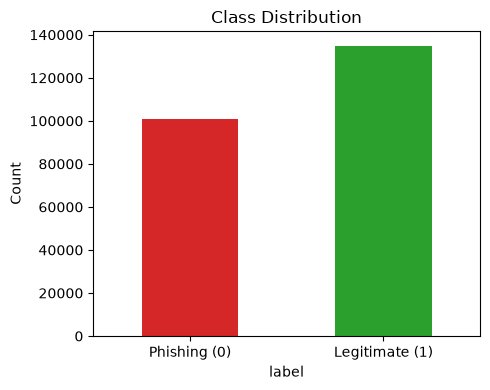

In [8]:
import matplotlib.pyplot as plt

label_counts = df['label'].value_counts().sort_index()
print(label_counts)
print(f"Phishing (0): {label_counts.get(0,0)/len(df)*100:.2f}%")
print(f"Legitimate (1): {label_counts.get(1,0)/len(df)*100:.2f}%")

plt.figure(figsize=(5, 4))
label_counts.plot(kind='bar', color=['#d62728', '#2ca02c'])
plt.xticks([0, 1], ['Phishing (0)', 'Legitimate (1)'], rotation=0)
plt.ylabel('Count')
plt.title('Class Distribution')
plt.tight_layout()
plt.savefig(os.path.join(EDA_PLOTS_DIR, "class_distribution.png"), dpi=150)
plt.show()


### 5.3 URL Length by Class

A quick sanity check on whether URL length alone separates the classes.

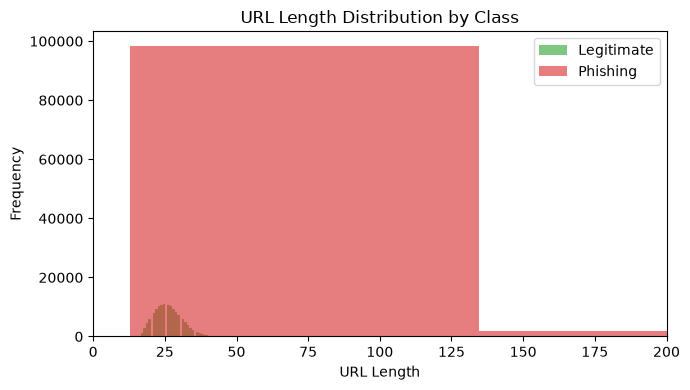

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100945.0,45.720293,61.145523,13.0,26.0,34.0,48.0,6097.0
1,134850.0,26.228610,4.815612,15.0,23.0,26.0,29.0,57.0


In [9]:
plt.figure(figsize=(7, 4))
df[df['label'] == 1]['URLLength'].plot(kind='hist', bins=50, alpha=0.6, label='Legitimate', color='#2ca02c')
df[df['label'] == 0]['URLLength'].plot(kind='hist', bins=50, alpha=0.6, label='Phishing', color='#d62728')
plt.xlabel('URL Length')
plt.ylabel('Frequency')
plt.title('URL Length Distribution by Class')
plt.legend()
plt.xlim(0, 200)
plt.tight_layout()
plt.savefig(os.path.join(EDA_PLOTS_DIR, "url_length_by_class.png"), dpi=150)
plt.show()

df.groupby('label')['URLLength'].describe()


### 5.4 HTTPS Usage by Class

Phishing sites have historically skewed toward not using HTTPS, though this gap has narrowed as certificates became free and easy to obtain.

            No HTTPS   HTTPS
Phishing       50.78   49.22
Legitimate      0.00  100.00


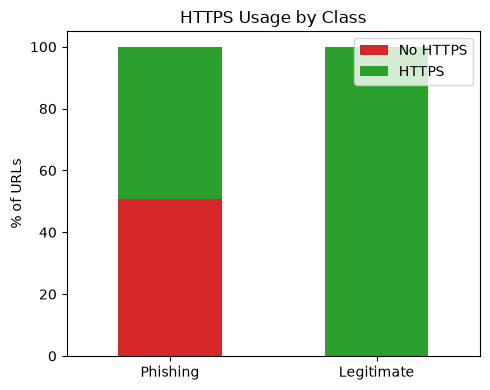

In [10]:
https_by_label = pd.crosstab(df['label'], df['IsHTTPS'], normalize='index') * 100
https_by_label.columns = ['No HTTPS', 'HTTPS']
https_by_label.index = ['Phishing', 'Legitimate']
print(https_by_label.round(2))

https_by_label.plot(kind='bar', stacked=True, figsize=(5, 4), color=['#d62728', '#2ca02c'])
plt.ylabel('% of URLs')
plt.title('HTTPS Usage by Class')
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.savefig(os.path.join(EDA_PLOTS_DIR, "https_usage_by_class.png"), dpi=150)
plt.show()


### 5.5 Top TLDs

Most common top-level domains in the dataset, split by class.

TLD
com    112554
org     18793
net      7097
app      6508
uk       6395
co       5422
io       4201
de       3996
ru       3875
au       2979
Name: count, dtype: int64


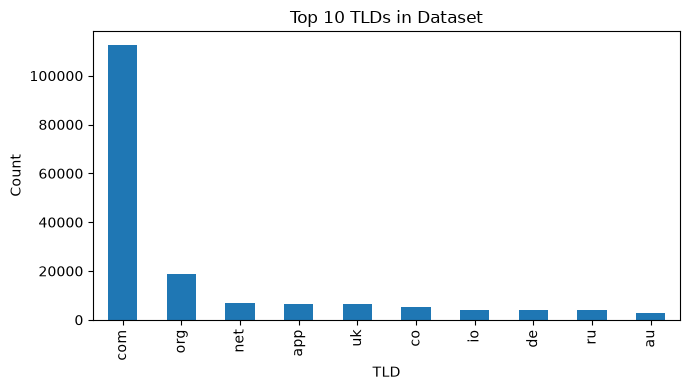

In [11]:
top_tlds = df['TLD'].value_counts().head(10)
print(top_tlds)

plt.figure(figsize=(7, 4))
top_tlds.plot(kind='bar', color='#1f77b4')
plt.ylabel('Count')
plt.title('Top 10 TLDs in Dataset')
plt.tight_layout()
plt.savefig(os.path.join(EDA_PLOTS_DIR, "top_10_tlds.png"), dpi=150)
plt.show()


### 5.6 Correlation Snapshot

Correlation of a handful of the dataset's own numeric features with the label, just to spot obviously strong (or leaky) signals before feature extraction. Note some of these columns — like `URLSimilarityIndex` — were later excluded from the deployed feature set as leaky, as documented in the model card.

In [12]:
numeric_preview = ['URLLength', 'DomainLength', 'URLSimilarityIndex', 'CharContinuationRate',
                    'TLDLegitimateProb', 'NoOfSubDomain', 'IsHTTPS', 'label']
numeric_preview = [c for c in numeric_preview if c in df.columns]
corr = df[numeric_preview].corr(numeric_only=True)['label'].sort_values(ascending=False)
corr


label                   1.000000
URLSimilarityIndex      0.860358
IsHTTPS                 0.609132
CharContinuationRate    0.467735
TLDLegitimateProb       0.097389
NoOfSubDomain          -0.005955
URLLength              -0.233445
DomainLength           -0.283152
Name: label, dtype: float64

## 6. Build Feature Matrix\n\nApply the extraction function to every URL to reproduce the exact features the Streamlit app generates at inference time.

In [13]:
print("Generating Streamlit Features... (This takes about 15-30 seconds)")
X_data = df['URL'].apply(streamlit_extract).tolist()
X = pd.DataFrame(X_data, columns=cols)
y = df['label']

X.shape, y.shape

Generating Streamlit Features... (This takes about 15-30 seconds)


((235795, 21), (235795,))

## 7. Train/Test Split and Scaling

In [14]:
print("Scaling Data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Scaling Data...


## 8. Model Architecture\n\n128 → 64 → 32 → 1, with dropout for regularization.

In [15]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\aksha\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Train the Model\n\nEarly stopping on validation loss to avoid overfitting.

In [16]:
print("Training Model...")
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Training Model...
Epoch 1/20
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9709 - loss: 0.0853 - val_accuracy: 0.9892 - val_loss: 0.0446
Epoch 2/20
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9894 - loss: 0.0387 - val_accuracy: 0.9930 - val_loss: 0.0273
Epoch 3/20
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9925 - loss: 0.0306 - val_accuracy: 0.9940 - val_loss: 0.0240
Epoch 4/20
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9931 - loss: 0.0286 - val_accuracy: 0.9949 - val_loss: 0.0216
Epoch 5/20
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9929 - loss: 0.0287 - val_accuracy: 0.9945 - val_loss: 0.0221
Epoch 6/20
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9935 - loss: 0.0274 - val_accuracy: 0.9945 - val_loss: 0.0218
Epoch 7/20
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9936 - loss: 0.0272 - val_accuracy: 0.9947 - val_loss: 0.0220


   1/2358 ━━━━━━━━━━━━━━━━━━━━ 41:05 1s/step - accuracy: 0.4688 - loss: 0.7133

  36/2358 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8060 - loss: 0.5592  

  73/2358 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8639 - loss: 0.4151

 106/2358 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8890 - loss: 0.3407

...

2208/2358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9939 - loss: 0.0261

2252/2358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9939 - loss: 0.0261

2296/2358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9939 - loss: 0.0261

2339/2358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9938 - loss: 0.0262

2358/2358 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9938 - loss: 0.0263 - val_accuracy: 0.9949 - val_loss: 0.0216


## 10. Evaluate on Held-out Test Set

In [17]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.9944
Test Loss: 0.0240


## 11. Save Artifacts\n\nSaves the model, scaler, and feature column list — all three are required by the Streamlit app for consistent inference.

In [18]:
print("Saving files...")
model.save("phishing_ann_model.keras")
joblib.dump(scaler, "phishing_scaler.pkl")
joblib.dump(cols, "phishing_feature_columns.pkl")
print("Done! Files successfully overwritten.")

Saving files...
Done! Files successfully overwritten.
